# P-VAE revisit

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'PoissonVAE'))
from figures.fighelper import *
from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

model_type = 'poisson'

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', model_type, 'lin|lin')
print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_ch': 32, 'n_latents': 512, 'prior_clamp': -4, 'fit_prior': True, 'enc_type': 'lin', 
'dec_type': 'lin', 'enc_bias': False, 'dec_bias': False, 'init_dist': 'Normal', 'init_scale': 0.05}

Trainer:
{'lr': 0.005, 'batch_size': 1000, 'epochs': 3000, 'optimizer_kws': {'weight_decay': 0.0}, 'grad_clip': 500, 
'kl_const_portion': 0.0}

/home/hadi/Dropbox/git/PoissonVAE/base/train_base.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(


poisson_uniform_c(-4)_vH16_z-512_fp_nrm-none_<lin|lin>
mc_b1000-ep3000-lr(0.005)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2026_01_05,19:23)

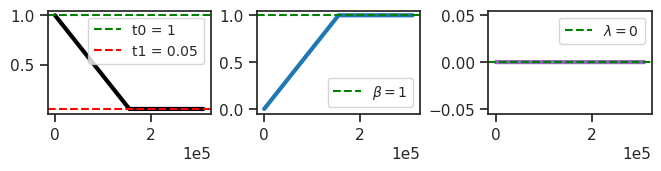

In [4]:
vae = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = TrainerVAE(vae, ConfigTrainVAE(**cfg_tr), device=device)

print(f"{vae.cfg.name()}\n{tr.cfg.name()}_({vae.timestamp})\n")
tr.show_schedules()

In [5]:
print(vae)

PoissonVAE(
  (mse): MSELoss()
  (fc_enc): Linear(in_features=256, out_features=512, bias=False)
  (fc_dec): Linear(in_features=512, out_features=256, bias=False)
)

In [6]:
comment = f"sigmoid_{tr.cfg.name()}"
# comment = tr.cfg.name()
tr.train(fit_name=comment)

  0%|                                                  | 0/3000 [00:00<?, ?it/s]/home/hadi/Dropbox/git/PoissonVAE/main/train_vae.py:343: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.cfg.use_amp):
epoch # 3000, avg loss: 165.109888: 100%|█| 3000/3000 [1:57:31<00:00,  2.35s/it]


## vld

In [7]:
data, loss, rates = tr.validate()

_loss = {k: v.mean() for k, v in loss.items()}
_loss['tot'] = _loss['mse'] + _loss['kl']
print(_loss)

{'r2': 0.2626517, 'mse': 137.21419, 'kl': 32.404213, 'kl_diag': 0.06328392, 'tot': 169.61841}

In [9]:
lifetime, population, percents = sparse_score(data['z'], cutoff=0.05)
print(percents)

{'0': 73.6, '1': 18.9, '2': 4.9, '3+': 2.5}

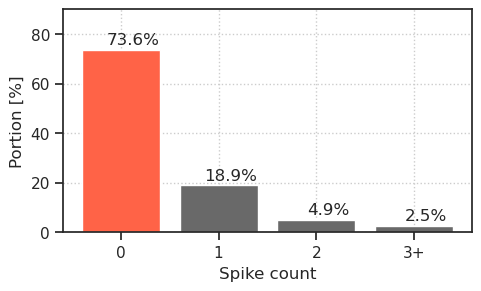

In [10]:
fig, ax = create_figure(1, 1, (4.7, 2.8))

max_val = float(list(percents.values())[0])
ax.set(
    xlabel='Spike count',
    ylabel='Portion [%]',
    ylim=(0, (np.ceil(max_val / 10) + 1) * 10),
)
colors = ['tomato' if lbl == '0' else 'dimgrey' for lbl in percents]
bars = ax.bar(percents.keys(), percents.values(), color=colors)

for bar in bars:
    y = bar.get_height()
    x = bar.get_x() + 1.3 * bar.get_width() / 2
    plt.text(x, y + 1, f'{y:0.1f}%', ha='center', va='bottom')

ax.locator_params(axis='y', nbins=5)

ax.grid()
plt.show()

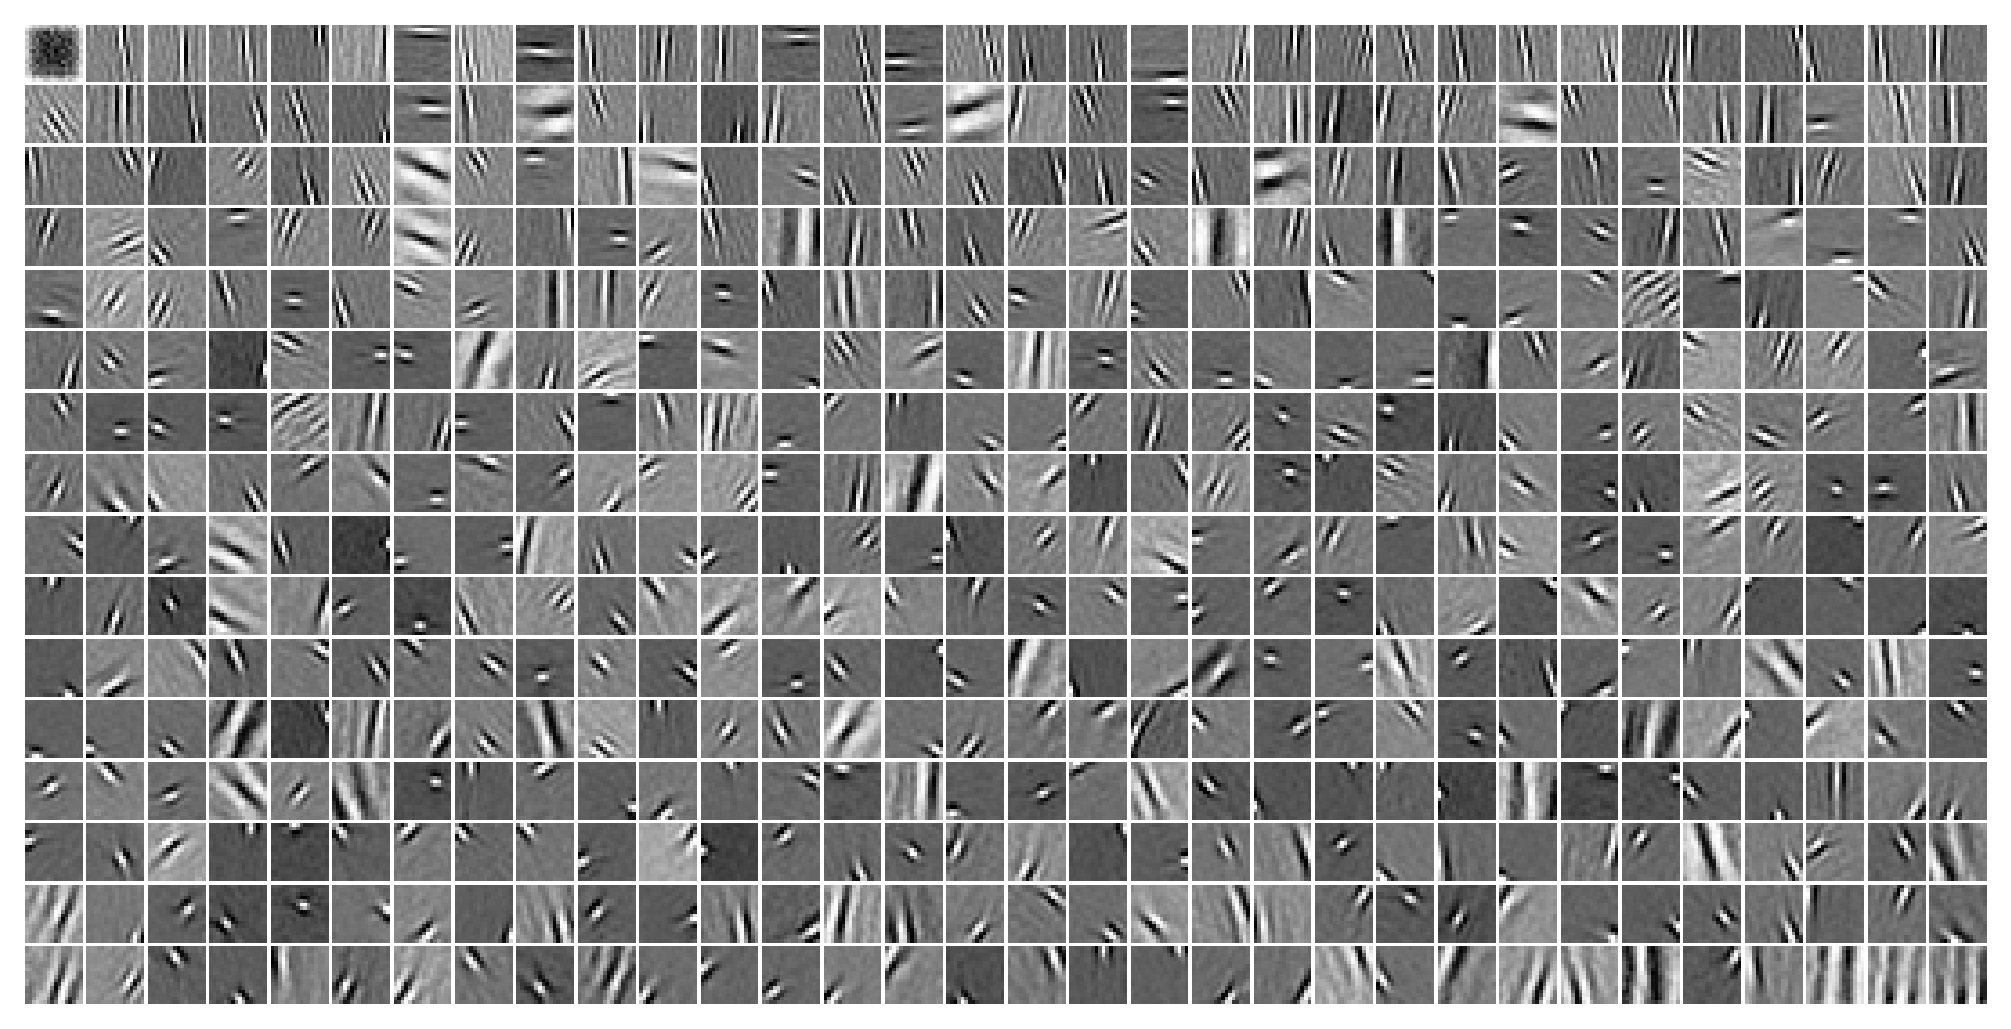

In [13]:
vae.show(dpi=250, order=np.argsort(tonp(vae.log_rate.squeeze())));

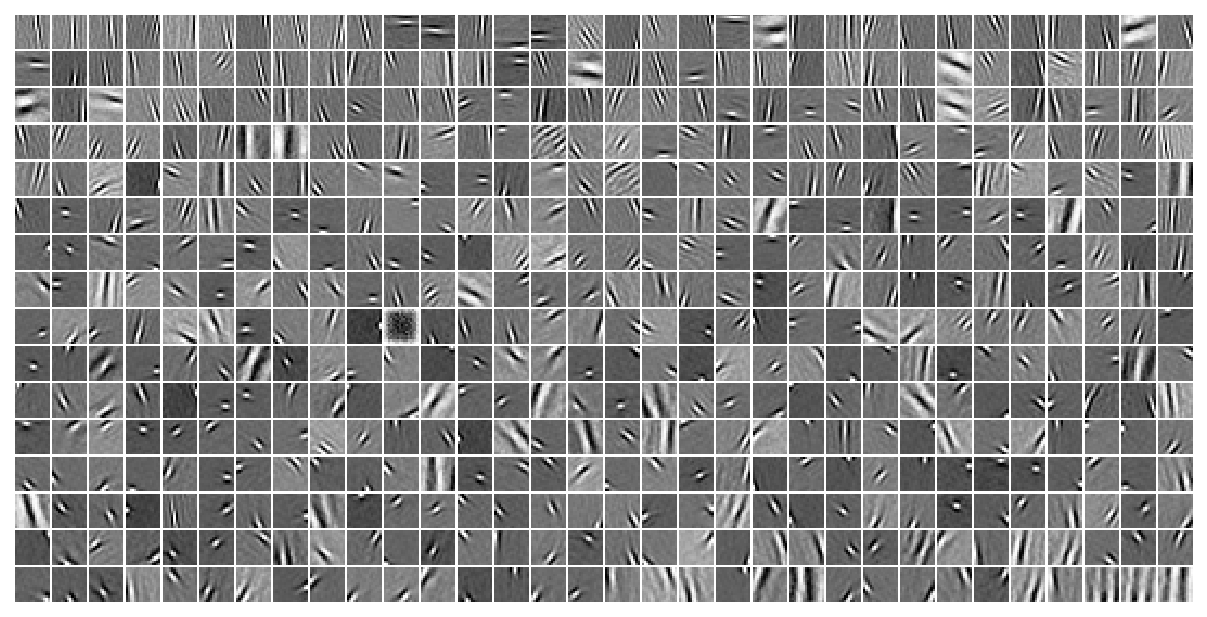

In [14]:
vae.show(dpi=150, order=np.argsort(loss['kl_diag']));